In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support,accuracy_score,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE
import joblib, os

In [2]:
df = pd.read_csv('D:/cse/SEM5/INT234/Project/model_ready.csv')
X = df.drop(columns=['is_productive','is_healthy'], errors='ignore')
y = df['is_productive']

In [3]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [4]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [5]:
lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)
lgbm.fit(X_res, y_res)

[LightGBM] [Info] Number of positive: 20164, number of negative: 20164
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006726 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2492
[LightGBM] [Info] Number of data points in the train set: 40328, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(learning_rate=0.05, n_estimators=500, random_state=42)

In [6]:
probs = lgbm.predict_proba(X_val)[:,1]
preds = (probs >= 0.5).astype(int)

In [7]:
auc = roc_auc_score(y_val, probs)
prec, rec, f1, _ = precision_recall_fscore_support(y_val, preds, average='binary')
metrics = {'model':'LightGBM','auc':auc,'precision':prec,'recall':rec,'f1':f1}


Model: LightGBM
Accuracy: 0.8793333333333333
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      5041
           1       0.64      0.56      0.60       959

    accuracy                           0.88      6000
   macro avg       0.78      0.75      0.76      6000
weighted avg       0.87      0.88      0.88      6000



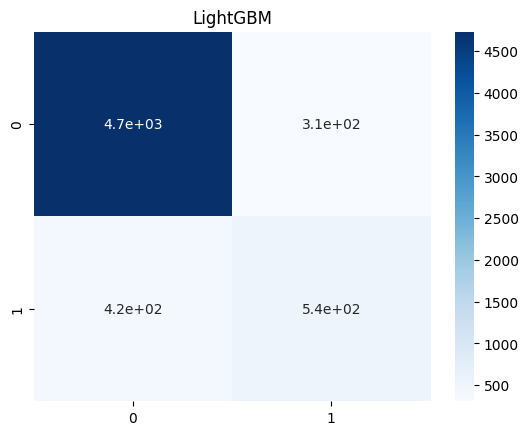

In [8]:
print(f"\nModel: LightGBM")
print("Accuracy:", accuracy_score(y_val,preds))
print(classification_report(y_val, preds))
sns.heatmap(confusion_matrix(y_val,preds), annot=True, cmap="Blues")
plt.title("LightGBM")
plt.show()

In [9]:
joblib.dump(lgbm, 'D:/cse/SEM5/INT234/Project/models/lgbm_smote.pkl')

['D:/cse/SEM5/INT234/Project/models/lgbm_smote.pkl']

In [10]:
pd.DataFrame([metrics]).to_csv('D:/cse/SEM5/INT234/Project/results/model_metrics.csv', mode='a', header=not os.path.exists('D:/cse/SEM5/INT234/Project/results/model_metrics.csv'), index=False)